In [1]:
import os
os.getcwd()

'/Users/samswitz/GitHub/mech-int/notebooks'

In [2]:
os.chdir("/Users/samswitz/GitHub/mech-int")

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from transformers import AutoTokenizer

/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
EXPANSION = 8

In [5]:
metrics = pd.read_csv(f"training_metrics/training_metrics_{EXPANSION}x.csv")

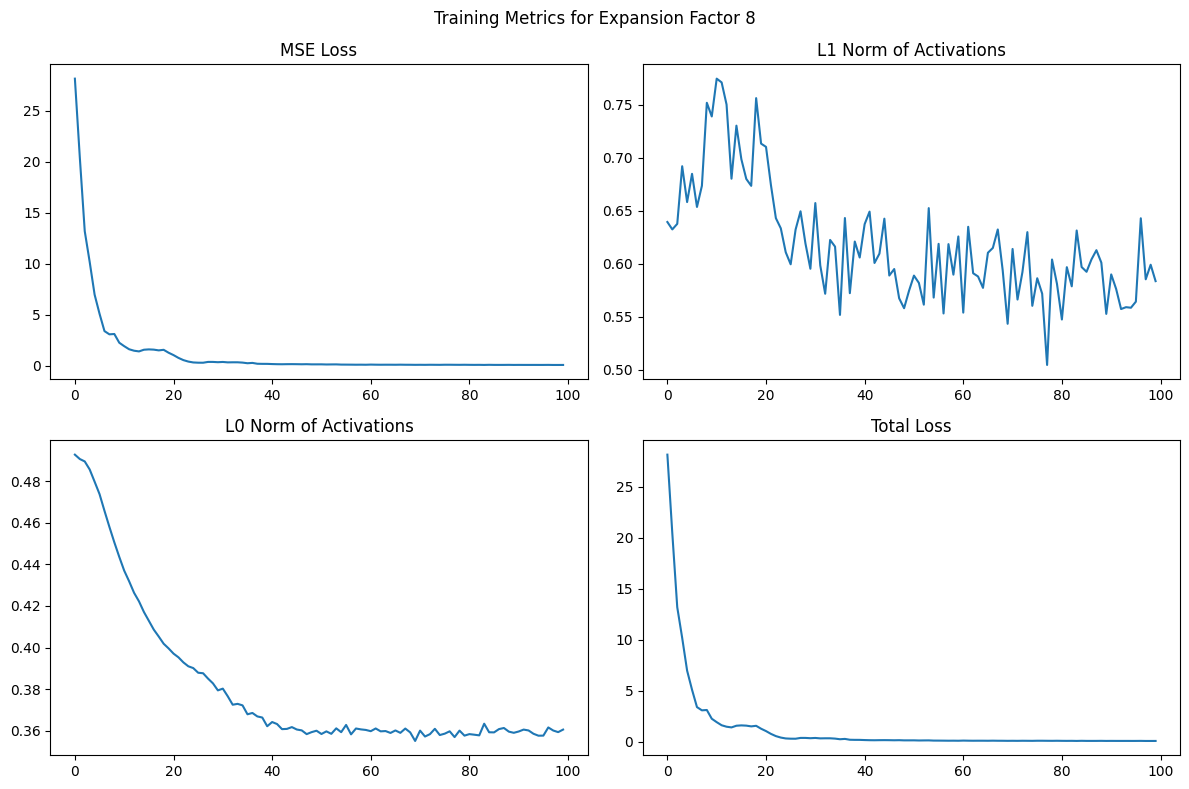

In [6]:
# Add a title that says "Training Metrics for Expansion Factor {EXPANSION}"
plt.figure(figsize=(12, 8))
plt.suptitle(f'Training Metrics for Expansion Factor {EXPANSION}')
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [7]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load tokenizer only (no need for the full model)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")

MODEL_PATH = f"saved_models/sae_model_{EXPANSION}x.pt"

# Load saved SAE
d = 512
m = d * EXPANSION
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
sae.eval()

# Load activations and process through SAE encoder in batches
# Full encoder output would be ~88GB, so we process in chunks
NUM_TEXTS = 50000
ACTIVATIONS_PATH = f"activations/activations_{NUM_TEXTS}.pt"

activations = torch.load(ACTIVATIONS_PATH, map_location="cpu")
n_tokens = activations.shape[0]
BATCH_SIZE = 4096

# We only need top-k per feature, so we track running top-k instead of storing everything
K = 20  # track top-K activating tokens per feature
top_vals = torch.zeros(m, K)
top_idxs = torch.full((m, K), -1, dtype=torch.long)

with torch.no_grad():
    for start in tqdm.trange(0, n_tokens, BATCH_SIZE):
        batch = activations[start:start + BATCH_SIZE]
        feat_acts = sae.encoder(batch)  # (batch, m)

        for j in range(feat_acts.shape[1]):
            combined_vals = torch.cat([top_vals[j], feat_acts[:, j]])
            combined_idxs = torch.cat([top_idxs[j], torch.arange(start, start + feat_acts.shape[0])])
            best = combined_vals.topk(K)
            top_vals[j] = best.values
            top_idxs[j] = combined_idxs[best.indices]

del activations

# Re-tokenize the same texts to get token strings
# TransformerLens prepends a BOS token per text, so we must do the same
dataset = load_dataset("openwebtext", split="train", streaming=True)
BOS = tokenizer.bos_token_id

all_tokens = []
all_contexts = []
for i, example in enumerate(tqdm.tqdm(dataset, total=NUM_TEXTS)):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    token_ids = [BOS] + tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode(tid) for tid in token_ids]
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}, activations: {n_tokens}")
assert len(all_tokens) == n_tokens, f"Mismatch! tokens={len(all_tokens)} vs activations={n_tokens}"
print(f"Tracked top-{K} activations for {m} features")

100%|██████████| 50000/50000 [00:27<00:00, 1792.19it/s]

Total tokens: 5884867, activations: 5884867
Tracked top-20 activations for 4096 features


In [8]:
def inspect_feature(feature_idx, k=10):
    k = min(k, K)
    vals = top_vals[feature_idx, :k]
    idxs = top_idxs[feature_idx, :k]

    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(vals, idxs):
        idx = idx.item()
        if idx < 0:
            break
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(1273)

Feature 1273 — top 10 activating tokens:

  4.127  token=         ' ele'   context: (Lula Marques/AGPT)

SÃO PAULO - O relator da reforma política na comissão espec
  4.116  token=         ' foi'   context: KARINA MATIAS DO "AGORA"

Publicidade

Um funcionário da CPTM (Companhia Paulist
  3.972  token=          ' da'   context: (Lula Marques/AGPT)

SÃO PAULO - O relator da reforma política na comissão espec
  3.948  token=          ' da'   context: KARINA MATIAS DO "AGORA"

Publicidade

Um funcionário da CPTM (Companhia Paulist
  3.889  token=           ' a'   context: KARINA MATIAS DO "AGORA"

Publicidade

Um funcionário da CPTM (Companhia Paulist
  3.871  token=         ' foi'   context: KARINA MATIAS DO "AGORA"

Publicidade

Um funcionário da CPTM (Companhia Paulist
  3.823  token=        ' para'   context: NATUZA NERY EDITORA DO PAINEL

Publicidade

"Dona Dilma" abre a porta, ao lado d
  3.797  token=          ' há'   context: Luciano Velleda

Da RBA

Morador do Recreio dos Bandeir

In [9]:
# Features where the best activation is 0 are dead
alive_mask = top_vals[:, 0] > 0
dead_count = (~alive_mask).sum().item()

# Sort alive features by their top activation (lowest = sparsest)
alive_idxs = torch.where(alive_mask)[0]
sorted_order = top_vals[alive_idxs, 0].argsort()
sparsest_idxs = alive_idxs[sorted_order]
# sparsest_idxs = torch.tensor([1896])

print(f"Dead features: {dead_count} / {m}")
print()
for idx in sparsest_idxs[:10]:
    idx = idx.item()
    # Count non-zero entries in top-K as a proxy
    n_active = (top_vals[idx] > 0).sum().item()
    print(f"Feature {idx}: top activation = {top_vals[idx, 0]:.4f} ({n_active}/{K} top slots active)")
    inspect_feature(idx, k=5)
    print()

Dead features: 4 / 4096

Feature 1846: top activation = 0.0017 (1/20 top slots active)
Feature 1846 — top 5 activating tokens:

  0.002  token=          ' 10'   context: At 10 o’clock in the evening we arrived. The train stopped. We went onto the pla

Feature 3638: top activation = 0.0057 (1/20 top slots active)
Feature 3638 — top 5 activating tokens:

  0.006  token=        ' held'   context: BAGHDAD — As Iraq emerges from three years of war with the Islamic State group, 

Feature 691: top activation = 0.0068 (1/20 top slots active)
Feature 691 — top 5 activating tokens:

  0.007  token=        ' like'   context: Formula 1's omnipresent pursuit of safety usually remains under the radar and it

Feature 1233: top activation = 0.0082 (4/20 top slots active)
Feature 1233 — top 5 activating tokens:

  0.008  token=      ' series'   context: While popular documentary films like Fahrenheit 9/11 and No End In Sight explore
  0.005  token=            '0'   context: Cornucopia 0.3.3 - Legendari

In [10]:
# Rank features by strongest top activation
best_per_feature = top_vals[:, 0]
ranked = best_per_feature.argsort(descending=True)

for rank, idx in enumerate(ranked[:20]):
    idx = idx.item()
    print(f"=== Rank {rank+1}: Feature {idx} (top activation: {best_per_feature[idx]:.3f}) ===")
    inspect_feature(idx, k=5)
    print()

=== Rank 1: Feature 3289 (top activation: 168.386) ===
Feature 3289 — top 5 activating tokens:

  168.386  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  162.418  token=            '.'   context: Self-driving electric cars? Rad!! A Hyperloop train that can get you from New Yo
  162.109  token=            '.'   context: Fox News Channel pundits Greta Van Susteren and Erick Erickson have gone to war 
  161.757  token=            '.'   context: According to court documents, 29-year-old Markus Kaarma of Missoula, Mont. was i
  161.663  token=            '.'   context: Poison Ivy is a 1985 American made-for-television romantic comedy film starring 

=== Rank 2: Feature 3348 (top activation: 28.609) ===
Feature 3348 — top 5 activating tokens:

  28.609  token=            '.'   context: At MWC 2016, OPPO released its new SmartSensor image stabilization technology. A
  28.554  token=            '.'   context: A local police o

In [11]:
# Find the most "interpretable" features: ones where top-K tokens are consistent
# Score = fraction of top-K tokens that match the most common token
# Filter out single-char punctuation which dominates the max-activation ranking
from collections import Counter

BORING = {'.', "'", '-', '"', ',', '!', '?', ':', ';', '\n', ' ', ''}

scores = []
for feat_idx in range(m):
    idxs = top_idxs[feat_idx]
    valid = idxs[idxs >= 0]
    if len(valid) < 5:
        scores.append((feat_idx, 0.0, ""))
        continue
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    most_common_token, most_common_count = counts.most_common(1)[0]
    consistency = most_common_count / len(tokens)
    scores.append((feat_idx, consistency, most_common_token))

# Sort by consistency, filter out punctuation-only features
scores_filtered = [(idx, score, tok) for idx, score, tok in scores
                   if tok.strip() not in BORING and len(tok.strip()) > 0]
scores_filtered.sort(key=lambda x: -x[1])

print("Most consistent (interpretable) features:\n")
for feat_idx, consistency, top_token in scores_filtered[:30]:
    # if len(top_token) == 2:
    #     continue
    print(f"Feature {feat_idx}: {consistency:.0%} consistent, top token = {repr(top_token)}, max act = {top_vals[feat_idx, 0]:.3f}")
    inspect_feature(feat_idx, k=5)
    print()

Most consistent (interpretable) features:

Feature 1: 100% consistent, top token = ' ca', max act = 1.808
Feature 1 — top 5 activating tokens:

  1.808  token=          ' ca'   context: Star forward Eddie Betts will be entertaining Crows fans for years to come after
  1.757  token=          ' ca'   context: The family of Michael Brown appeared on NBC’s “Today” show, during which they we
  1.752  token=          ' ca'   context: Credit: Marvel Comics

Horror fiction icon R.L. Stine makes his comic book writi
  1.740  token=          ' ca'   context: Twenty years after helping his injured son across the finish line in Barcelona, 
  1.722  token=          ' ca'   context: TO HEAR Gov. Larry Hogan (R) tell it, Maryland is sinking fast, its people fleei

Feature 2: 100% consistent, top token = ' Feb', max act = 2.194
Feature 2 — top 5 activating tokens:

  2.194  token=         ' Feb'   context: Peter G. Aiken/Getty Images

The Cleveland Browns have endured another regime ch
  2.157  token=

# W_dec Cosine Similarity Analysis

In [12]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Normalize decoder weights and compute pairwise cosine similarity
W_dec = sae.W_dec.data.clone()  # (m, d)
W_dec_normed = W_dec / W_dec.norm(dim=1, keepdim=True)
cos_sim = W_dec_normed @ W_dec_normed.T  # (m, m)

# Zero out the diagonal for analysis (self-similarity = 1 is uninteresting)
cos_sim_no_diag = cos_sim.clone()
cos_sim_no_diag.fill_diagonal_(0)

print(f"Decoder weight matrix: {W_dec.shape}")
print(f"Cosine similarity matrix: {cos_sim.shape}")
print(f"Max off-diagonal similarity: {cos_sim_no_diag.max():.4f}")
print(f"Mean off-diagonal similarity: {cos_sim_no_diag.sum() / (m * (m - 1)):.4f}")

Decoder weight matrix: torch.Size([4096, 512])
Cosine similarity matrix: torch.Size([4096, 4096])
Max off-diagonal similarity: 0.8024
Mean off-diagonal similarity: 0.0015


In [13]:
# cos_sim[1403][339]
print(cos_sim[1273][1315])
print(cos_sim[476][1315])
print(cos_sim[1273][476])

# 1403 & 339

# np.std(cos_sim_no_diag.cpu().numpy())

tensor(0.0272)
tensor(-0.0632)
tensor(-0.0552)


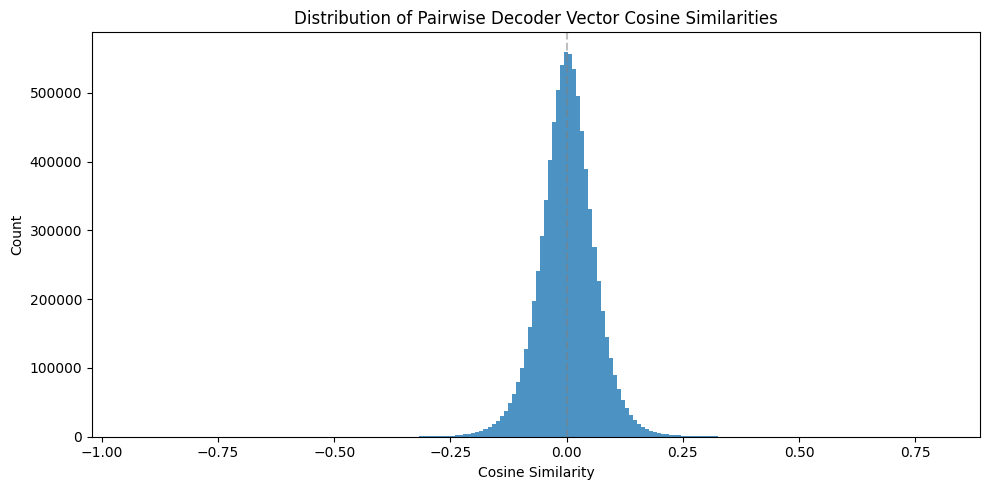

Pairs with |cos_sim| > 0.5: 472
Pairs with |cos_sim| > 0.7: 80
Pairs with |cos_sim| > 0.9: 11


In [14]:
# Histogram of pairwise cosine similarities (upper triangle only to avoid double-counting)
upper_tri = cos_sim[torch.triu(torch.ones(m, m, dtype=torch.bool), diagonal=1)].numpy()

plt.figure(figsize=(10, 5))
plt.hist(upper_tri, bins=200, edgecolor='none', alpha=0.8)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Distribution of Pairwise Decoder Vector Cosine Similarities")
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Pairs with |cos_sim| > 0.5: {(np.abs(upper_tri) > 0.5).sum()}")
print(f"Pairs with |cos_sim| > 0.7: {(np.abs(upper_tri) > 0.7).sum()}")
print(f"Pairs with |cos_sim| > 0.9: {(np.abs(upper_tri) > 0.9).sum()}")

In [15]:
# Inspect the most similar feature pairs, skipping features whose top token is a single char
N_PAIRS = 20
sim_flat = cos_sim_no_diag.flatten()
top_pair_indices = sim_flat.argsort(descending=True)

def top_token(feat_idx):
    idx = top_idxs[feat_idx, 0].item()
    return all_tokens[idx].strip() if idx >= 0 else ""

print(f"Top {N_PAIRS} most similar feature pairs (filtered to meaningful tokens):\n")
seen = set()
count = 0
for flat_idx in top_pair_indices:
    if count >= N_PAIRS:
        break
    i = flat_idx.item() // m
    j = flat_idx.item() % m
    pair = (min(i, j), max(i, j))
    if pair in seen:
        continue
    seen.add(pair)
    # Skip pairs where either feature's top token is a single character or empty
    tok_i, tok_j = top_token(i), top_token(j)
    if len(tok_i) <= 1 or len(tok_j) <= 1:
        continue
    sim_val = cos_sim[i, j].item()
    print(f"Features {i} & {j}: cosine sim = {sim_val:.4f}")
    inspect_feature(i, k=3)
    inspect_feature(j, k=3)
    print("-" * 80)
    count += 1

Top 20 most similar feature pairs (filtered to meaningful tokens):

Features 3041 & 3961: cosine sim = 0.7074
Feature 3041 — top 3 activating tokens:

  6.853  token=         ' may'   context: Dragon's Dogma

Capcom

Rated By Our Customers Compatible with PlayStation 3™ (P
  6.819  token=        ' will'   context: About

So please, support us TODAY and be part of the Holiplay experience where 
  6.657  token=        ' will'   context: This is a design for a hotel room with a king-size bed at the Old Post Office bu
Feature 3961 — top 3 activating tokens:

  5.334  token=           '10'   context: Blog Archive Mar 2018 (2) Feb 2018 (5) Jan 2018 (9) Dec 2017 (1) Apr 2017 (4) Ma
  5.117  token=         'uchi'   context: Jones

vs.

Cormier Cerrone

vs.

Jury Tavares

vs.

Marquardt Horiguchi

vs.

G
  4.915  token=            '3'   context: July (1) January (1) November (1) September (2) June (1) March (1) January (1) N
----------------------------------------------------------------------

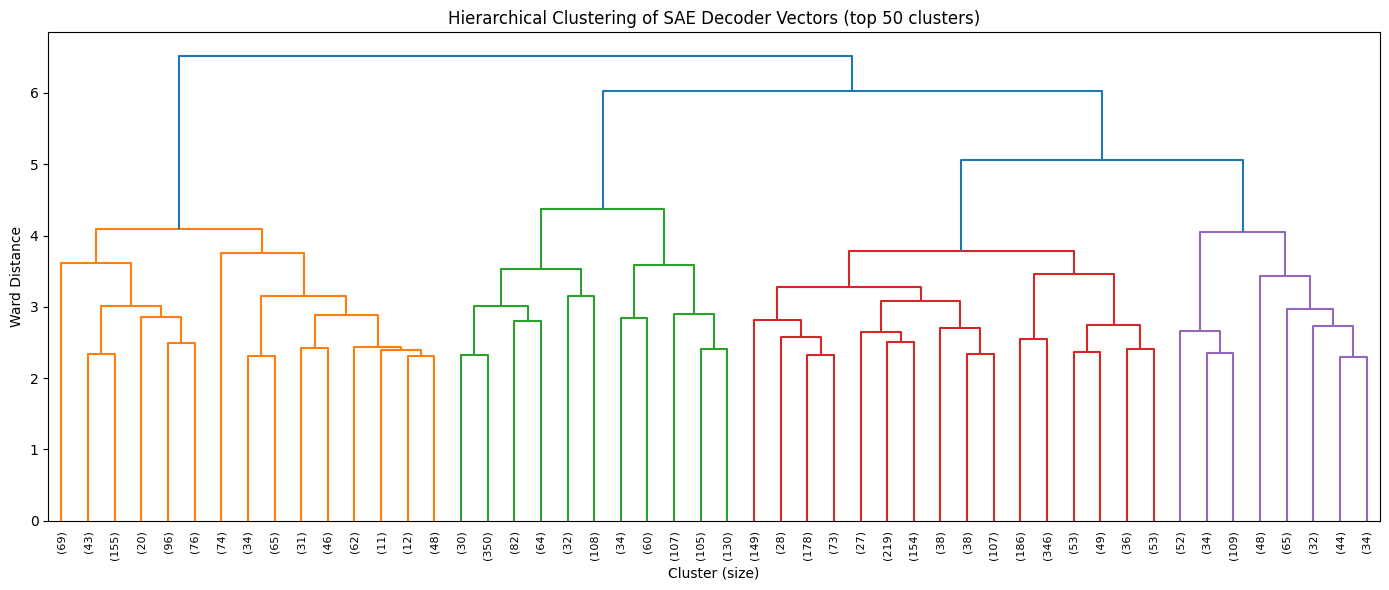

In [16]:
# Hierarchical clustering of decoder vectors + dendrogram
# Use cosine distance = 1 - cosine_similarity
cos_dist = 1 - cos_sim.numpy()
np.fill_diagonal(cos_dist, 0)
cos_dist = np.clip(cos_dist, 0, 2)  # ensure no negative distances from floating point

condensed_dist = squareform(cos_dist)
Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90, leaf_font_size=8,
           show_leaf_counts=True)
plt.title("Hierarchical Clustering of SAE Decoder Vectors (top 50 clusters)")
plt.xlabel("Cluster (size)")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [22]:
def search_token(query, k=5):
    """Find features whose top-K activating tokens match the query.
    
    Matches any token containing the query string (case-insensitive).
    """
    results = []
    for feat_idx in range(m):
        idxs = top_idxs[feat_idx]
        valid = idxs[idxs >= 0]
        for rank, tok_idx in enumerate(valid[:K]):
            tok = all_tokens[tok_idx.item()]
            if query.lower() in tok.lower():
                results.append((feat_idx, rank, top_vals[feat_idx, rank].item(), tok))
                break  # only count best rank per feature

    results.sort(key=lambda x: x[1])  # sort by rank (0 = top token)
    print(f"Features with '{query}' in top-{K} tokens: {len(results)}\n")
    for feat_idx, rank, val, tok in results[:20]:
        print(f"  Feature {feat_idx}: rank={rank}, activation={val:.3f}, token={repr(tok)}")
    return results

# Example usage:
search_token("London")
print()

Features with 'London' in top-20 tokens: 3

  Feature 454: rank=2, activation=2.352, token=' London'
  Feature 2218: rank=5, activation=2.621, token=' London'
  Feature 1637: rank=7, activation=3.010, token=' London'



In [23]:
inspect_feature(454, k=10)
# inspect_feature(1315, k=10)

Feature 454 — top 10 activating tokens:

  2.652  token=       ' World'   context: The page is currently under construction.

Future Card Buddyfight World Champion
  2.551  token=          ' TT'   context: Media playback is not supported on this device TT racer Ian Hutchinson has his l
  2.352  token=      ' London'   context: Image zoom Splash News Online

Rafael Nadal will not be competing in the London 
  2.332  token=    ' Canadian'   context: FC Edmonton and the Vancouver Whitecaps finished on level terms in the first leg
  2.313  token=           'op'   context: Gadon: In order to rescue your Jedi friend, you’ll have to win her in the swoop 
  2.261  token=         'rade'   context: Grimsby Town 1-1 Sunderland U21 (Sunderland win 7-6 on penalties)

safc.com’s Sa
  2.228  token=       ' World'   context: The page is currently under construction.

Future Card Buddyfight World Champion
  2.223  token=       ' World'   context: U17 MEN 2-0 round one of the FIBA World Championships

Z

In [53]:
inspect_feature(445, k=10)
inspect_feature(476, k=10)

Feature 445 — top 10 activating tokens:

  5.590  token=          'The'   context: The Apple Watch is set sell millions in its first year on shelves. Already the n
  5.590  token=          'The'   context: The world’s first monkeys with genes modified through a DNA engineering method k
  5.590  token=          'The'   context: The upcoming Men’s EHF EURO 2016 in Poland will be the chance for all handball f
  5.590  token=          'The'   context: The GDP-growth figure released today, at 3.5%, was slightly higher than expected
  5.590  token=          'The'   context: The religious group known as the Blackburn Cult, the Divine Order of the Royal A
  5.590  token=          'The'   context: The Catholic Archdiocese of Kansas City has decided to cut ties with the Girl Sc
  5.590  token=          'The'   context: The percentage of working-age Canadians who aren’t working – who aren’t even loo
  5.590  token=          'The'   context: The view from Mount Sunflower, Kansas’s highest elevatio

In [52]:
def token_counts(feature_idx):
    """Show unique tokens in the top-K activations for a feature and their counts."""
    idxs = top_idxs[feature_idx]
    valid = idxs[idxs >= 0]
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    print(f"Feature {feature_idx} — unique tokens in top-{len(tokens)} activations:")
    for tok, count in counts.most_common():
        print(f"  {count:3d}x  {repr(tok)}")
    print()

token_counts(1273)
token_counts(1315)

Feature 1273 — unique tokens in top-20 activations:
   20x  '.'

Feature 1315 — unique tokens in top-20 activations:
   20x  '.'

